<a href="https://colab.research.google.com/github/M-EL-YAMANI/M-EL-YAMANI/blob/main/Barrage_LSTM_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 Prédiction du Débit Entrant au Barrage — Modèle LSTM

**Objectif :** Prédire le débit journalier entrant au barrage à partir des débits mesurés aux stations amont (M'Douar, Oughane, M'ghar, Bouffarah) en utilisant un modèle LSTM avec mécanisme d'attention.

**Architecture :**
- Encodeur Bi-LSTM : capture les dépendances temporelles sur une fenêtre de 14 jours
- Décodeur LSTM + Attention : génère la prédiction pour le jour J
- Variables d'entrée : débits stations amont + encodage cyclique du temps
- Variable cible : débit au barrage (m³/s)

## 1. Importation des bibliothèques

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU disponible     : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
GPU disponible     : False


## 2. Chargement et exploration des données

In [12]:
df = pd.read_csv('dataset_1979_2007.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("=== Aperçu du dataset ===")
print(f"Période       : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Nombre de jours : {len(df):,}")
print(f"Colonnes      : {df.columns.tolist()}")
print(f"\nValeurs manquantes :\n{df.isna().sum()}")
print("\nStatistiques descriptives :")
display(df.describe().round(3))

=== Aperçu du dataset ===
Période       : 1979-09-01 → 2007-08-31
Nombre de jours : 10,227
Colonnes      : ['Date', 'Barrage', "M'Douar", 'Oughane', "M'ghar", 'Bouffarah']

Valeurs manquantes :
Date         0
Barrage      0
M'Douar      0
Oughane      0
M'ghar       0
Bouffarah    0
dtype: int64

Statistiques descriptives :


,Date,Barrage,M'Douar,Oughane,M'ghar,Bouffarah
count,10227,10227.000,10227.000,10227.000,10227.000,10227.000
mean,1993-08-31 00:00:00,18.067,10.416,2.500,0.885,3.683
min,1979-09-01 00:00:00,0.000,0.000,0.000,0.000,0.000
25%,1986-08-31 12:00:00,0.000,0.154,0.012,0.014,0.060
50%,1993-08-31 00:00:00,1.769,0.912,0.181,0.072,0.398
75%,2000-08-30 12:00:00,9.988,5.306,1.187,0.367,2.046
max,2007-08-31 00:00:00,1487.199,1029.627,252.659,58.377,262.627
std,NaN,67.045,37.984,10.246,3.252,12.227


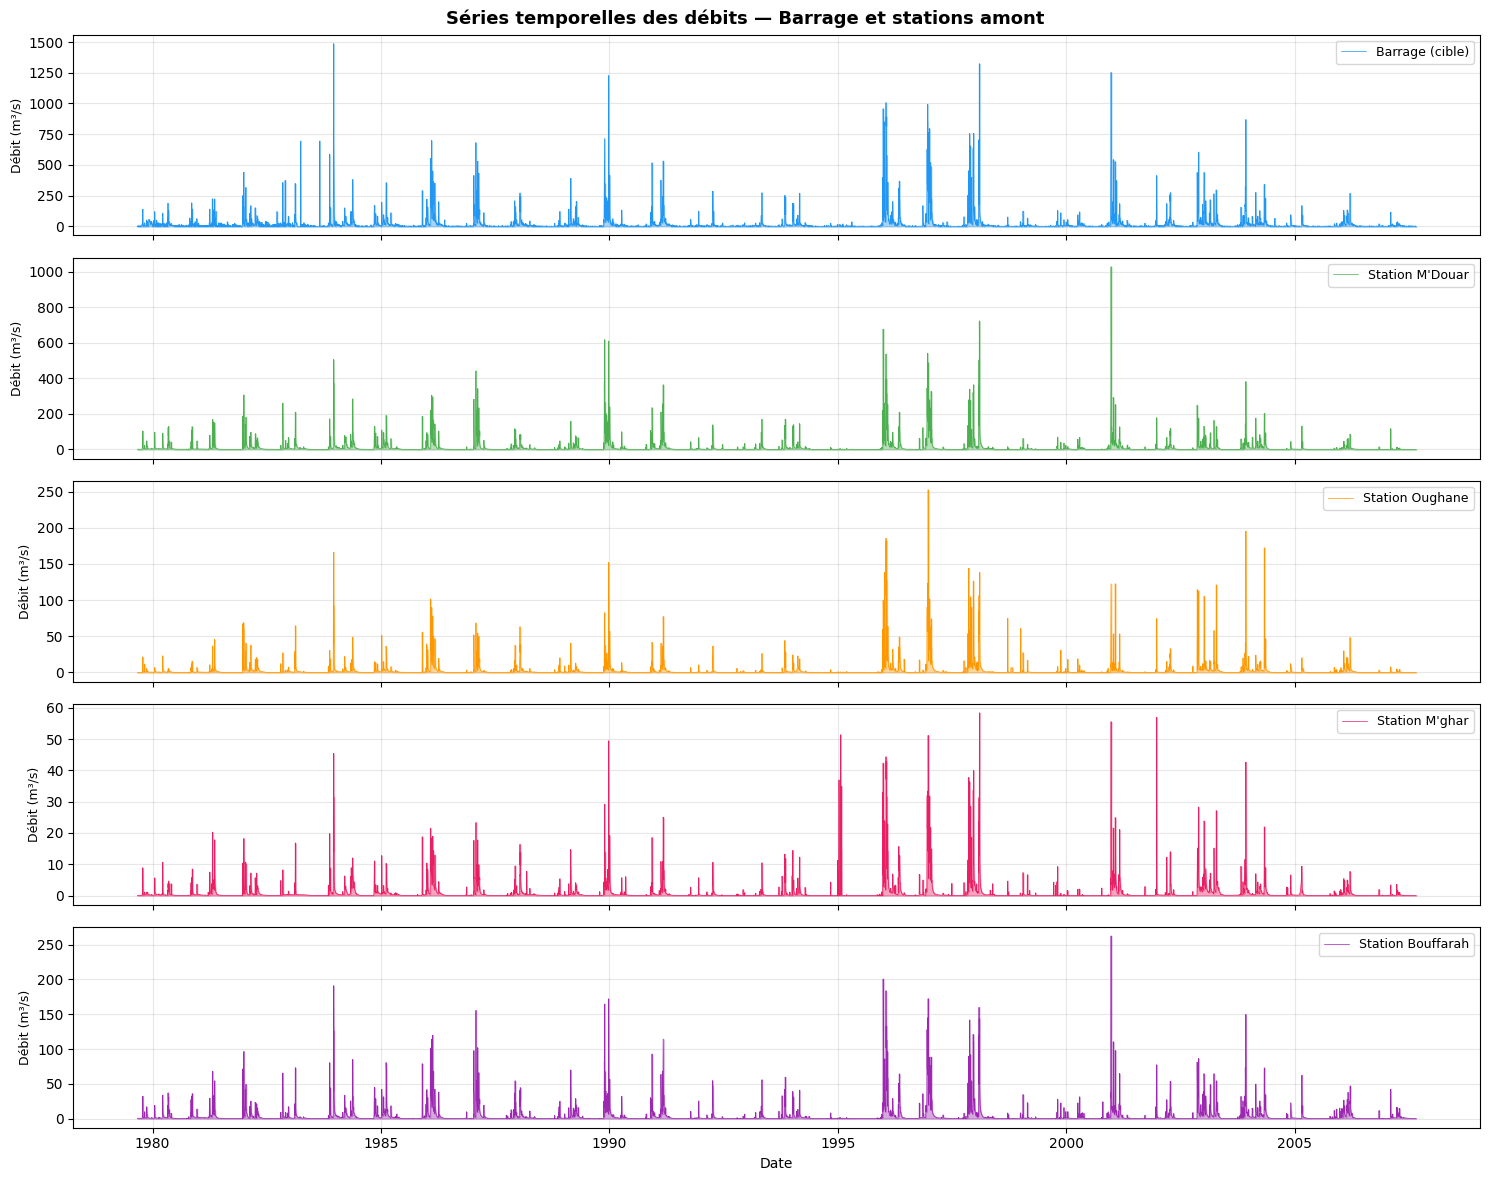

In [13]:
# Visualisation des séries temporelles
fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

stations = ['Barrage', "M'Douar", 'Oughane', "M'ghar", 'Bouffarah']
colors   = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
labels   = ['Barrage (cible)', "Station M'Douar", 'Station Oughane', "Station M'ghar", 'Station Bouffarah']

for ax, col, color, label in zip(axes, stations, colors, labels):
    ax.fill_between(df['Date'], df[col], alpha=0.4, color=color)
    ax.plot(df['Date'], df[col], color=color, linewidth=0.5, label=label)
    ax.set_ylabel('Débit (m³/s)', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
plt.xlabel('Date', fontsize=10)
fig.suptitle('Séries temporelles des débits — Barrage et stations amont', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('series_temporelles.png', dpi=150, bbox_inches='tight')
plt.show()

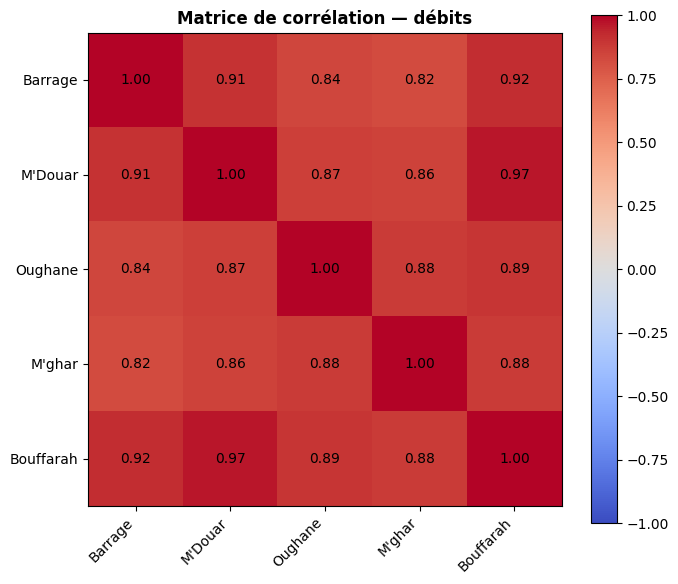

In [14]:
# Matrice de corrélation
corr = df[stations].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(stations)))
ax.set_yticks(range(len(stations)))
ax.set_xticklabels(stations, rotation=45, ha='right')
ax.set_yticklabels(stations)
for i in range(len(stations)):
    for j in range(len(stations)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('Matrice de corrélation — débits', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Ingénierie des features

In [15]:
df_feat = df.copy()

# Encodage cyclique du temps
df_feat['month']     = df_feat['Date'].dt.month
df_feat['dayofyear'] = df_feat['Date'].dt.dayofyear
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
df_feat['doy_sin']   = np.sin(2 * np.pi * df_feat['dayofyear'] / 365)
df_feat['doy_cos']   = np.cos(2 * np.pi * df_feat['dayofyear'] / 365)

STATION_COLS = ["M'Douar", 'Oughane', "M'ghar", 'Bouffarah']
SEASON_COLS  = ['month_sin', 'month_cos', 'doy_sin', 'doy_cos']
TARGET_COL   = 'Barrage'
ALL_FEATURES = STATION_COLS + SEASON_COLS

print("Features d'entrée (stations amont) :", STATION_COLS)
print("Features saisonnières              :", SEASON_COLS)
print("Variable cible                     :", TARGET_COL)
print(f"Total features                     : {len(ALL_FEATURES)}")

Features d'entrée (stations amont) : ["M'Douar", 'Oughane', "M'ghar", 'Bouffarah']
Features saisonnières              : ['month_sin', 'month_cos', 'doy_sin', 'doy_cos']
Variable cible                     : Barrage
Total features                     : 8


## 4. Division train / validation / test

Entraînement : 1979-09-01 → 1999-08-31  (7,305 jours)
Validation   : 1999-09-01 → 2003-08-31  (1,461 jours)
Test         : 2003-09-01 → 2007-08-31  (1,461 jours)


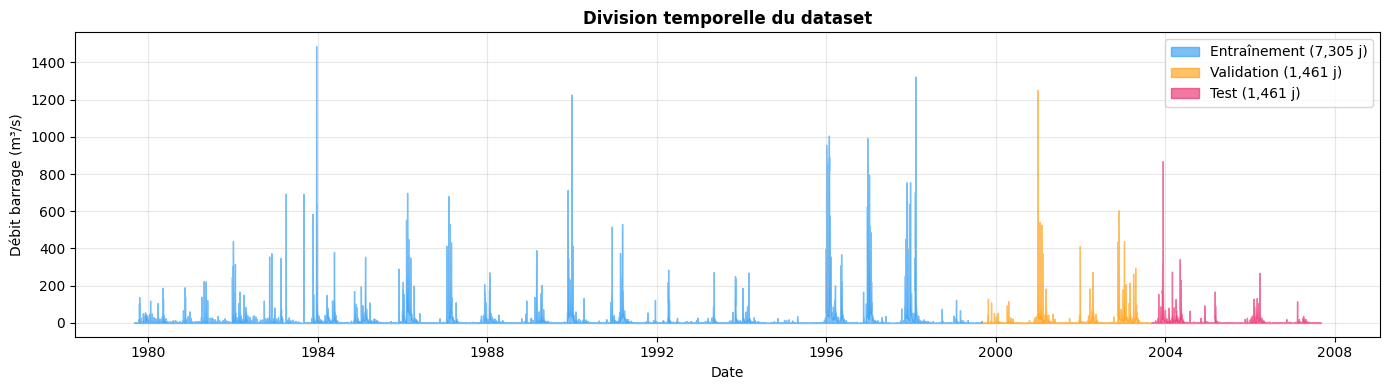

In [16]:
CUTOFF_VAL  = '1999-08-31'
CUTOFF_TEST = '2003-08-31'

train_df = df_feat[df_feat['Date'] <= CUTOFF_VAL].copy().reset_index(drop=True)
val_df   = df_feat[(df_feat['Date'] > CUTOFF_VAL) & (df_feat['Date'] <= CUTOFF_TEST)].copy().reset_index(drop=True)
test_df  = df_feat[df_feat['Date'] > CUTOFF_TEST].copy().reset_index(drop=True)

print(f"Entraînement : {train_df['Date'].min().date()} → {train_df['Date'].max().date()}  ({len(train_df):,} jours)")
print(f"Validation   : {val_df['Date'].min().date()} → {val_df['Date'].max().date()}  ({len(val_df):,} jours)")
print(f"Test         : {test_df['Date'].min().date()} → {test_df['Date'].max().date()}  ({len(test_df):,} jours)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(train_df['Date'], train_df[TARGET_COL], alpha=0.6, color='#2196F3', label=f'Entraînement ({len(train_df):,} j)')
ax.fill_between(val_df['Date'],   val_df[TARGET_COL],   alpha=0.6, color='#FF9800', label=f'Validation ({len(val_df):,} j)')
ax.fill_between(test_df['Date'],  test_df[TARGET_COL],  alpha=0.6, color='#E91E63', label=f'Test ({len(test_df):,} j)')
ax.set_xlabel('Date'); ax.set_ylabel('Débit barrage (m³/s)')
ax.set_title('Division temporelle du dataset', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Normalisation des données

In [17]:
def log_transform(arr):
    return np.log1p(arr)

def inv_log_transform(arr):
    return np.expm1(arr)

scaler_stations = MinMaxScaler()
scaler_target   = StandardScaler()
scaler_flow     = StandardScaler()

# Features
X_train_raw = train_df[ALL_FEATURES].values
X_val_raw   = val_df[ALL_FEATURES].values
X_test_raw  = test_df[ALL_FEATURES].values

X_train_scaled = scaler_stations.fit_transform(X_train_raw)
X_val_scaled   = scaler_stations.transform(X_val_raw)
X_test_scaled  = scaler_stations.transform(X_test_raw)

# Cible : log1p + StandardScaler
y_train_log = log_transform(train_df[TARGET_COL].values).reshape(-1, 1)
y_val_log   = log_transform(val_df[TARGET_COL].values).reshape(-1, 1)
y_test_log  = log_transform(test_df[TARGET_COL].values).reshape(-1, 1)

y_train_scaled = scaler_target.fit_transform(y_train_log)
y_val_scaled   = scaler_target.transform(y_val_log)
y_test_scaled  = scaler_target.transform(y_test_log)

# Débit barrage passé (feature encodeur)
flow_train_scaled = scaler_flow.fit_transform(y_train_log)
flow_val_scaled   = scaler_flow.transform(y_val_log)
flow_test_scaled  = scaler_flow.transform(y_test_log)

print(f"X_train : {X_train_scaled.shape}")
print(f"X_val   : {X_val_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")

X_train : (7305, 8)
X_val   : (1461, 8)
X_test  : (1461, 8)


## 6. Création des fenêtres glissantes

In [18]:
WINDOW_SIZE = 14

def create_sliding_windows(X_feat, y_scaled, flow_scaled, window_size=14):
    encoder_X, decoder_X, y_labels = [], [], []
    for i in range(window_size, len(X_feat)):
        past_feat  = X_feat[i - window_size:i]
        past_flow  = flow_scaled[i - window_size:i].reshape(-1, 1)
        encoder_seq = np.hstack([past_feat, past_flow])
        today_feat  = X_feat[i].reshape(1, -1)
        encoder_X.append(encoder_seq)
        decoder_X.append(today_feat)
        y_labels.append(y_scaled[i])
    return np.array(encoder_X), np.array(decoder_X), np.array(y_labels)

enc_train, dec_train, y_tr = create_sliding_windows(X_train_scaled, y_train_scaled, flow_train_scaled, WINDOW_SIZE)
enc_val,   dec_val,   y_vl = create_sliding_windows(X_val_scaled,   y_val_scaled,   flow_val_scaled,   WINDOW_SIZE)
enc_test,  dec_test,  y_ts = create_sliding_windows(X_test_scaled,  y_test_scaled,  flow_test_scaled,  WINDOW_SIZE)

dates_train = train_df['Date'].values[WINDOW_SIZE:]
dates_val   = val_df['Date'].values[WINDOW_SIZE:]
dates_test  = test_df['Date'].values[WINDOW_SIZE:]

print(f"Encodeur train : {enc_train.shape}")
print(f"Décodeur train : {dec_train.shape}")
print(f"Cible train    : {y_tr.shape}")
print(f"Encodeur val   : {enc_val.shape}")
print(f"Encodeur test  : {enc_test.shape}")

Encodeur train : (7291, 14, 9)
Décodeur train : (7291, 1, 8)
Cible train    : (7291, 1)
Encodeur val   : (1447, 14, 9)
Encodeur test  : (1447, 14, 9)


## 7. Construction du modèle LSTM Encodeur-Décodeur avec Attention

In [19]:
TIMESTEPS    = WINDOW_SIZE
ENC_FEATURES = enc_train.shape[2]
DEC_FEATURES = dec_train.shape[2]
LATENT_DIM   = 128

print(f"Timesteps encodeur : {TIMESTEPS}")
print(f"Features encodeur  : {ENC_FEATURES}")
print(f"Features décodeur  : {DEC_FEATURES}")
print(f"Dimension latente  : {LATENT_DIM}")

def build_lstm_attention_model(timesteps, enc_features, dec_features, latent_dim=128, dropout=0.3):
    # Encodeur
    encoder_inputs = Input(shape=(timesteps, enc_features), name='encoder_input')
    enc_lstm = Bidirectional(
        LSTM(latent_dim, return_sequences=True, return_state=True, dropout=dropout),
        name='bi_lstm_encoder'
    )
    enc_out, fwd_h, fwd_c, bwd_h, bwd_c = enc_lstm(encoder_inputs)
    state_h = Concatenate(name='state_h')([fwd_h, bwd_h])
    state_c = Concatenate(name='state_c')([fwd_c, bwd_c])

    # Décodeur
    decoder_inputs = Input(shape=(1, dec_features), name='decoder_input')
    dec_lstm = LSTM(latent_dim * 2, return_sequences=True, return_state=True,
                    dropout=dropout, name='lstm_decoder')
    dec_out, _, _ = dec_lstm(decoder_inputs, initial_state=[state_h, state_c])
    dec_out = Dropout(dropout, name='dropout_decoder')(dec_out)

    # Attention dot-product
    score   = tf.keras.layers.Dot(axes=[2, 2], name='attention_score')([dec_out, enc_out])
    attn_w  = tf.keras.layers.Softmax(axis=-1, name='attention_weights')(score)
    context = tf.keras.layers.Dot(axes=[2, 1], name='context_vector')([attn_w, enc_out])

    # Fusion
    combined = Concatenate(axis=-1, name='combined')([context, dec_out])
    combined = Dropout(dropout)(combined)
    out      = Dense(32, activation='relu', name='dense_hidden')(combined)
    out      = Dense(1, name='output')(out)

    return Model(inputs=[encoder_inputs, decoder_inputs], outputs=out)

model = build_lstm_attention_model(
    timesteps=TIMESTEPS, enc_features=ENC_FEATURES,
    dec_features=DEC_FEATURES, latent_dim=LATENT_DIM, dropout=0.3
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.Huber(),
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

model.summary()

Timesteps encodeur : 14
Features encodeur  : 9
Features décodeur  : 8
Dimension latente  : 128


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 14, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_encoder     │ [(None, 14, 256), │    141,312 │ encoder_input[0]… │
│ (Bidirectional)     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 1, 8)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_h             │ (None, 256)       │          0 │ bi_lstm_encoder[… │
│ (Concatenate)       │                   │            │ bi_lstm_encoder[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_c             │ (None, 256)       │          0 │ bi_lstm_encoder[… │
│ (Concatenate)       │                   │            │ bi_lstm_encoder[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_decoder (LSTM) │ [(None, 1, 256),  │    271,360 │ decoder_input[0]… │
│                     │ (None, 256),      │            │ state_h[0][0],    │
│                     │ (None, 256)]      │            │ state_c[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_decoder     │ (None, 1, 256)    │          0 │ lstm_decoder[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 1, 14)     │          0 │ dropout_decoder[… │
│ (Dot)               │                   │            │ bi_lstm_encoder[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 1, 14)     │          0 │ attention_score[… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 1, 256)    │          0 │ attention_weight… │
│ (Dot)               │                   │            │ bi_lstm_encoder[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined            │ (None, 1, 512)    │          0 │ context_vector[0… │
│ (Concatenate)       │                   │            │ dropout_decoder[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1, 512)    │          0 │ combined[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 1, 32)     │     16,416 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1, 1)      │         33 │ dense_hidden[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 429,121 (1.64 MB)

 Trainable params: 429,121 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Entraînement du modèle

In [20]:
early_stopping = EarlyStopping(
    monitor='val_loss', patience=15, verbose=1,
    mode='min', restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7,
    verbose=1, min_lr=1e-6
)
checkpoint = ModelCheckpoint(
    'best_lstm_barrage.keras', monitor='val_loss',
    save_best_only=True, verbose=0
)

history = model.fit(
    [enc_train, dec_train],
    y_tr.reshape(-1, 1, 1),
    validation_data=([enc_val, dec_val], y_vl.reshape(-1, 1, 1)),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print(f"\nEntraînement terminé après {len(history.history['loss'])} epochs")
print("Clés disponibles dans history :", list(history.history.keys()))

Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 0.1931 - rmse: 0.6567 - val_loss: 0.1213 - val_rmse: 0.5086 - learning_rate: 0.0010
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 0.1652 - rmse: 0.6042 - val_loss: 0.1117 - val_rmse: 0.4894 - learning_rate: 0.0010
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.1506 - rmse: 0.5742 - val_loss: 0.1127 - val_rmse: 0.4942 - learning_rate: 0.0010
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 0.1460 - rmse: 0.5630 - val_loss: 0.1093 - val_rmse: 0.4798 - learning_rate: 0.0010
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.1420 - rmse: 0.5560 - val_loss: 0.0965 - val_rmse: 0.4531 - learning_rate: 0.0010
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.1384 - rmse: 0.5472 - val_loss: 0.1106 - val_rmse: 0.4836 - learning_rate: 0.0010
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.1363 - rmse: 0.5424 - val_loss: 0.1076 - val_rmse: 0.4762 -

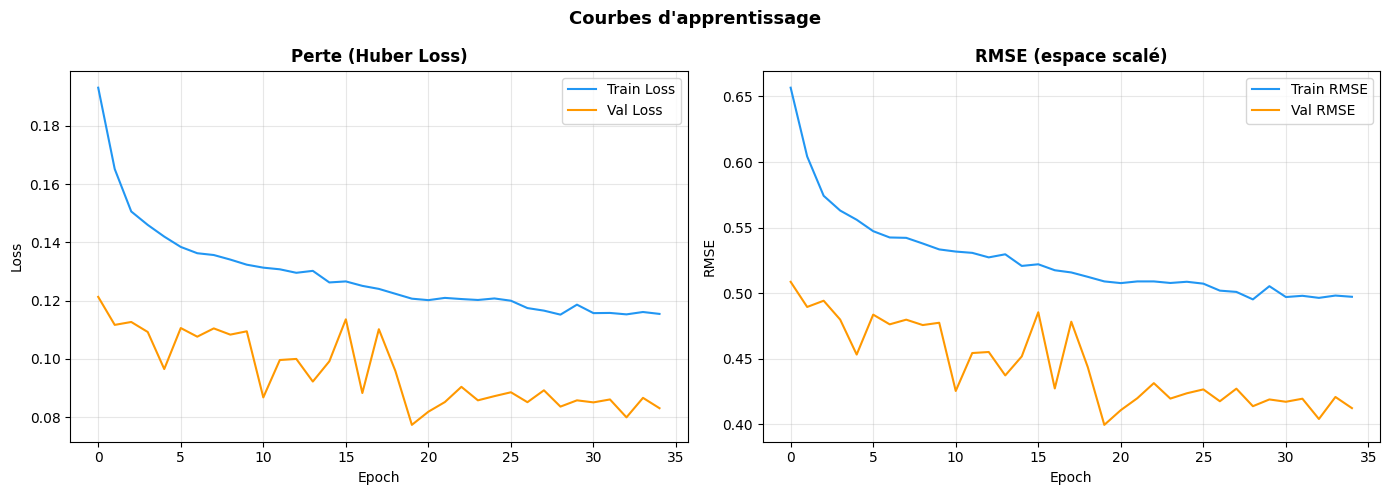

In [21]:
# Courbes d'apprentissage
# Détection automatique du nom de la métrique RMSE
rmse_key     = [k for k in history.history if k == 'rmse' or ('root' in k and 'val' not in k)][0]
val_rmse_key = 'val_' + rmse_key

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#FF9800')
axes[0].set_title('Perte (Huber Loss)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history[rmse_key],     label='Train RMSE', color='#2196F3')
axes[1].plot(history.history[val_rmse_key], label='Val RMSE',   color='#FF9800')
axes[1].set_title('RMSE (espace scalé)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('RMSE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Évaluation du modèle

In [22]:
def predict_and_inverse(enc_X, dec_X, y_scaled):
    y_pred_sc = model.predict([enc_X, dec_X], verbose=0)
    y_pred_log = scaler_target.inverse_transform(y_pred_sc.reshape(-1, 1))
    y_true_log = scaler_target.inverse_transform(y_scaled.reshape(-1, 1))
    y_pred_flow = np.clip(inv_log_transform(y_pred_log.flatten()), 0, None)
    y_true_flow = inv_log_transform(y_true_log.flatten())
    return y_pred_flow, y_true_flow

def compute_metrics(y_obs, y_sim, split_name=''):
    rmse  = np.sqrt(mean_squared_error(y_obs, y_sim))
    mae   = mean_absolute_error(y_obs, y_sim)
    r2    = r2_score(y_obs, y_sim)
    nse   = 1 - np.sum((y_sim - y_obs)**2) / np.sum((y_obs - np.mean(y_obs))**2)
    r     = np.corrcoef(y_sim, y_obs)[0, 1]
    alpha = np.std(y_sim) / np.std(y_obs)
    beta  = np.mean(y_sim) / np.mean(y_obs)
    kge   = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    print(f"\n{'='*40}\n  Métriques — {split_name}\n{'='*40}")
    print(f"  RMSE : {rmse:>10.3f} m³/s")
    print(f"  MAE  : {mae:>10.3f} m³/s")
    print(f"  R²   : {r2:>10.4f}")
    print(f"  NSE  : {nse:>10.4f}")
    print(f"  KGE  : {kge:>10.4f}")
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NSE': nse, 'KGE': kge}

pred_train, true_train = predict_and_inverse(enc_train, dec_train, y_tr)
pred_val,   true_val   = predict_and_inverse(enc_val,   dec_val,   y_vl)
pred_test,  true_test  = predict_and_inverse(enc_test,  dec_test,  y_ts)

metrics_train = compute_metrics(true_train, pred_train, 'ENTRAÎNEMENT')
metrics_val   = compute_metrics(true_val,   pred_val,   'VALIDATION')
metrics_test  = compute_metrics(true_test,  pred_test,  'TEST')


  Métriques — ENTRAÎNEMENT
  RMSE :     49.858 m³/s
  MAE  :      8.734 m³/s
  R²   :     0.5231
  NSE  :     0.5231
  KGE  :     0.7450

  Métriques — VALIDATION
  RMSE :     35.740 m³/s
  MAE  :      8.230 m³/s
  R²   :     0.6856
  NSE  :     0.6856
  KGE  :     0.7540

  Métriques — TEST
  RMSE :     13.838 m³/s
  MAE  :      4.018 m³/s
  R²   :     0.8605
  NSE  :     0.8605
  KGE  :     0.8240


In [23]:
# Tableau récapitulatif
metrics_df = pd.DataFrame({
    'Entraînement': metrics_train,
    'Validation':   metrics_val,
    'Test':         metrics_test
}).T.round(4)

print("\n📊 Résumé des performances :")
display(metrics_df)


📊 Résumé des performances :


,RMSE,MAE,R2,NSE,KGE
Entraînement,49.8582,8.7340,0.5231,0.5231,0.745
Validation,35.7403,8.2302,0.6856,0.6856,0.754
Test,13.8379,4.0184,0.8605,0.8605,0.824


## 10. Visualisation des résultats

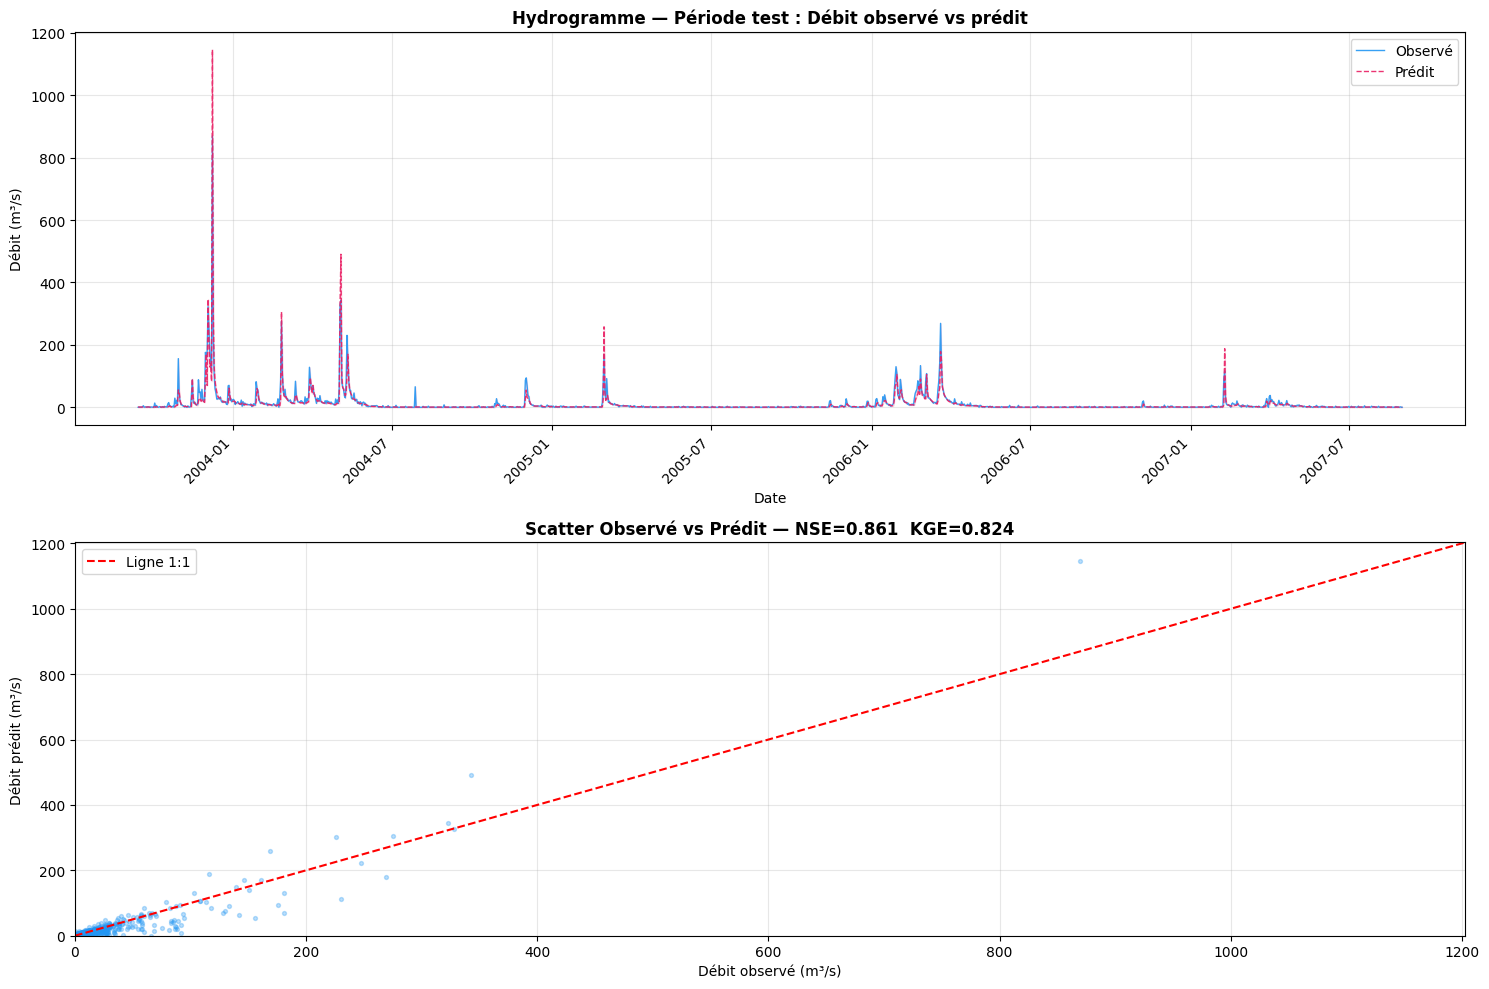

In [24]:
# Hydrogramme — période test
dates_test_pd = pd.to_datetime(dates_test)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

ax = axes[0]
ax.plot(dates_test_pd, true_test, color='#2196F3', linewidth=1.0, label='Observé', alpha=0.9)
ax.plot(dates_test_pd, pred_test, color='#E91E63', linewidth=1.0, label='Prédit',  alpha=0.9, linestyle='--')
ax.fill_between(dates_test_pd, true_test, pred_test, alpha=0.15, color='#E91E63')
ax.set_xlabel('Date'); ax.set_ylabel('Débit (m³/s)')
ax.set_title('Hydrogramme — Période test : Débit observé vs prédit', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2 = axes[1]
max_val = max(true_test.max(), pred_test.max()) * 1.05
ax2.scatter(true_test, pred_test, alpha=0.3, s=8, color='#2196F3')
ax2.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ligne 1:1')
ax2.set_xlabel('Débit observé (m³/s)'); ax2.set_ylabel('Débit prédit (m³/s)')
ax2.set_title(f'Scatter Observé vs Prédit — NSE={metrics_test["NSE"]:.3f}  KGE={metrics_test["KGE"]:.3f}', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max_val); ax2.set_ylim(0, max_val)

plt.tight_layout()
plt.savefig('resultats_test.png', dpi=150, bbox_inches='tight')
plt.show()

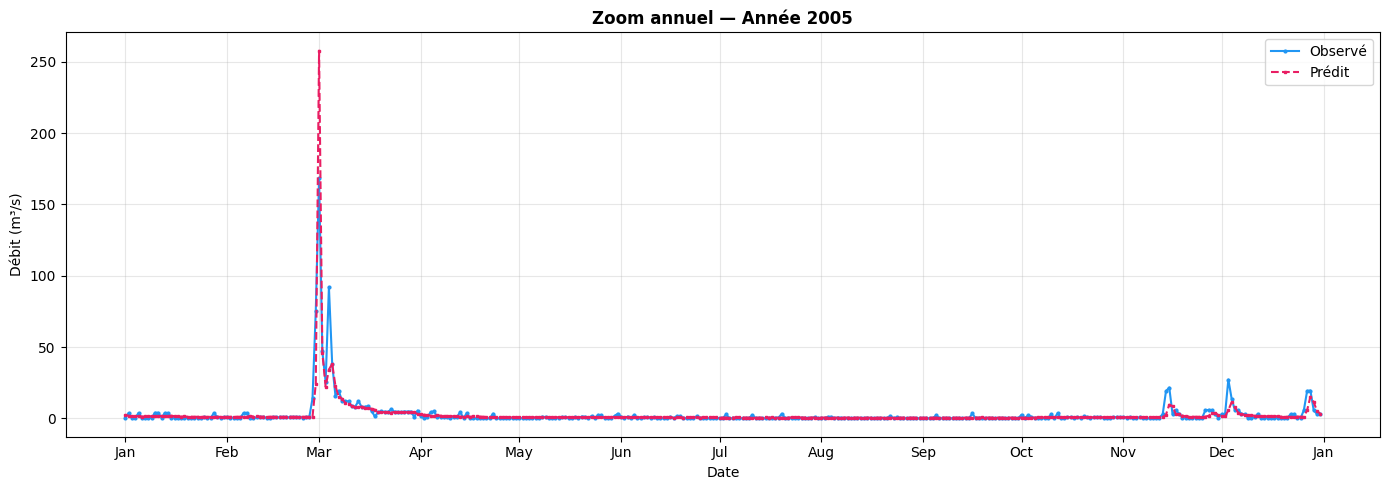

In [25]:
# Zoom sur une année de la période test
zoom_year = dates_test_pd[len(dates_test_pd) // 2].year
mask_year = dates_test_pd.year == zoom_year

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test_pd[mask_year], true_test[mask_year], color='#2196F3',
        linewidth=1.5, label='Observé', marker='o', markersize=2)
ax.plot(dates_test_pd[mask_year], pred_test[mask_year], color='#E91E63',
        linewidth=1.5, label='Prédit',  marker='s', markersize=2, linestyle='--')
ax.set_xlabel('Date'); ax.set_ylabel('Débit (m³/s)')
ax.set_title(f'Zoom annuel — Année {zoom_year}', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.savefig(f'zoom_{zoom_year}.png', dpi=150, bbox_inches='tight')
plt.show()

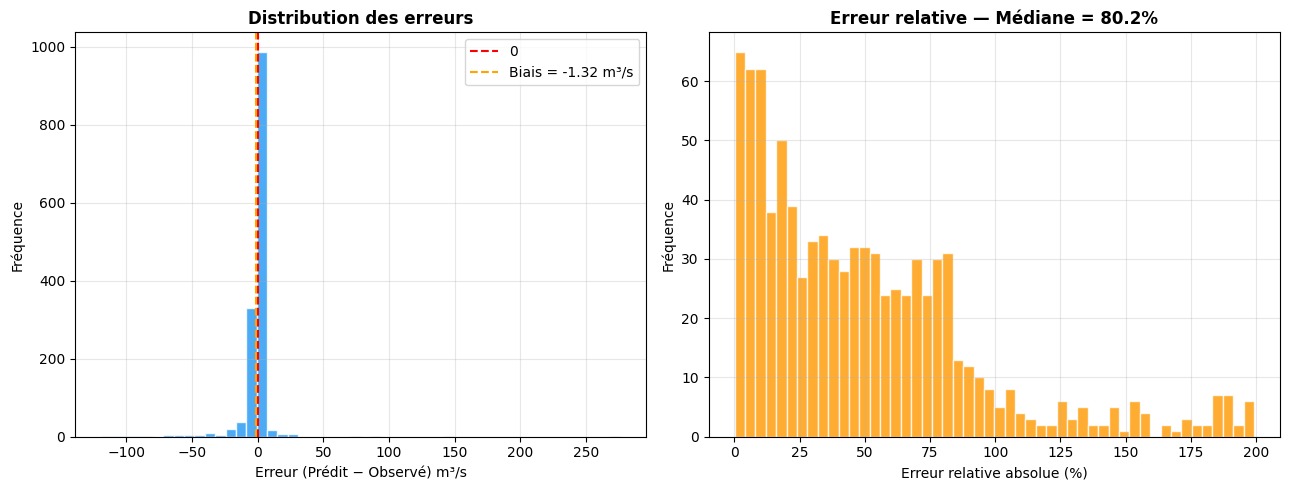

Biais moyen              : -1.318 m³/s
Erreur médiane relative  : 80.2%


In [26]:
# Distribution des erreurs
errors  = pred_test - true_test
rel_err = np.abs(errors) / (true_test + 1e-6) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(errors, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='0')
axes[0].axvline(np.mean(errors), color='orange', linestyle='--', linewidth=1.5,
                label=f'Biais = {np.mean(errors):.2f} m³/s')
axes[0].set_xlabel('Erreur (Prédit − Observé) m³/s')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des erreurs', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(rel_err[rel_err < 200], bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Erreur relative absolue (%)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Erreur relative — Médiane = {np.median(rel_err):.1f}%', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_erreurs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Biais moyen              : {np.mean(errors):.3f} m³/s")
print(f"Erreur médiane relative  : {np.median(rel_err):.1f}%")

## 11. Sauvegarde des résultats

In [27]:
import os

# Modèle
model.save('lstm_barrage_final.keras')
print("Modèle sauvegardé : lstm_barrage_final.keras")

# Prédictions
results_df = pd.DataFrame({
    'Date'    : pd.to_datetime(dates_test),
    'Observe' : true_test,
    'Predit'  : pred_test,
    'Erreur'  : pred_test - true_test
})
results_df.to_csv('predictions_test.csv', index=False)
print("Prédictions exportées : predictions_test.csv")

# Métriques
metrics_df.to_csv('metriques.csv')
print("Métriques exportées : metriques.csv")

print("\nFichiers générés :")
for f in ['lstm_barrage_final.keras', 'best_lstm_barrage.keras',
          'predictions_test.csv', 'metriques.csv',
          'series_temporelles.png', 'correlation_matrix.png',
          'data_split.png', 'learning_curves.png',
          'resultats_test.png', 'distribution_erreurs.png']:
    if os.path.exists(f):
        print(f"  ✓ {f:<40} ({os.path.getsize(f):,} bytes)")
    else:
        print(f"  ✗ {f} (non trouvé)")

Modèle sauvegardé : lstm_barrage_final.keras
Prédictions exportées : predictions_test.csv
Métriques exportées : metriques.csv

Fichiers générés :
  ✓ lstm_barrage_final.keras                 (5,223,418 bytes)
  ✓ best_lstm_barrage.keras                  (5,223,418 bytes)
  ✓ predictions_test.csv                     (76,478 bytes)
  ✓ metriques.csv                            (155 bytes)
  ✓ series_temporelles.png                   (317,833 bytes)
  ✓ correlation_matrix.png                   (79,533 bytes)
  ✓ data_split.png                           (100,568 bytes)
  ✓ learning_curves.png                      (118,049 bytes)
  ✓ resultats_test.png                       (187,740 bytes)
  ✓ distribution_erreurs.png                 (63,324 bytes)


## 12. Récapitulatif final

In [28]:
print("="*55)
print("  RÉSUMÉ — Prédiction du débit entrant au barrage")
print("="*55)
print(f"  Modèle    : Bi-LSTM Encodeur-Décodeur + Attention")
print(f"  Fenêtre   : {WINDOW_SIZE} jours")
print(f"  Période   : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Stations  : {', '.join(STATION_COLS)}")
print()
print(f"  {'Métrique':<8}  {'Train':>8}  {'Val':>8}  {'Test':>8}")
print(f"  {'-'*40}")
for m in ['RMSE', 'MAE', 'NSE', 'KGE', 'R2']:
    print(f"  {m:<8}  {metrics_train[m]:>8.3f}  {metrics_val[m]:>8.3f}  {metrics_test[m]:>8.3f}")
print("="*55)

  RÉSUMÉ — Prédiction du débit entrant au barrage
  Modèle    : Bi-LSTM Encodeur-Décodeur + Attention
  Fenêtre   : 14 jours
  Période   : 1979-09-01 → 2007-08-31
  Stations  : M'Douar, Oughane, M'ghar, Bouffarah

  Métrique     Train       Val      Test
  ----------------------------------------
  RMSE        49.858    35.740    13.838
  MAE          8.734     8.230     4.018
  NSE          0.523     0.686     0.861
  KGE          0.745     0.754     0.824
  R2           0.523     0.686     0.861
